# Simulación de política: quiebres vs sobrestock

Las notebooks 02 y 04 miden el **error del forecast**. Esta mide la **decisión**: si se hubiera repuesto con esta política durante los últimos 30 días, ¿cuántas unidades se habrían dejado de servir y cuánto stock habría hecho falta sostener?

Reglas de la simulación, iguales para todas las políticas:

- Revisión periódica cada 7 días, lead time 14 días
- Cada día: llegan los pedidos pendientes → se sirve la demanda con lo que hay → si toca revisión y la posición de inventario ha caído al punto de reorden, se pide hasta el objetivo
- Lo que no se sirve se **pierde**: no hay backorder
- Cada política arranca con su propio `target_stock` en almacén, así que paga desde el día 1 el stock que su regla exige

Todo lo que alimenta la decisión sale de datos anteriores al corte; el holdout solo consume stock.

> Requiere el paquete instalado en modo editable: `pip install -e .` desde la raíz del repo.

In [1]:
import pandas as pd

from inventario_ecommerce import config
from inventario_ecommerce.dataset import load_transactions, save_processed
from inventario_ecommerce.features import (
    clean_transactions,
    compute_abc_classification,
    prepare_daily_demand,
    sales_by_product_last_quarter,
)
from inventario_ecommerce.modeling.ets import forecast_ets_class_a
from inventario_ecommerce.modeling.simulate import (
    DEFAULT_POLICIES,
    ETS_POLICY,
    fill_rate_by_class,
    simulate_policies,
)
from inventario_ecommerce.plots import plot_policy_service_tradeoff

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Lead time:", config.LEAD_TIME_DAYS, "días")
print("Ciclo de revisión:", config.REVIEW_PERIOD_DAYS, "días")
print("z por clase:", config.SERVICE_Z_BY_CLASS)

Lead time: 14 días
Ciclo de revisión: 7 días
z por clase: {'A': 1.88, 'B': 1.65, 'C': 1.28}


## 1. Datos y forecast previo al corte

Misma higiene de demanda que el resto del pipeline. El ETS se ajusta **solo con la historia anterior al corte**, para que la política que lo usa no vea el holdout.

In [2]:
raw = load_transactions()
clean = clean_transactions(raw)
abc = compute_abc_classification(sales_by_product_last_quarter(clean))
daily = prepare_daily_demand(clean, abc=abc)

cutoff = pd.to_datetime(daily["Date"]).max() - pd.Timedelta(days=30)
train = daily[pd.to_datetime(daily["Date"]) <= cutoff]
ets_forecast = forecast_ets_class_a(train, abc, horizon_days=30)

print(f"Corte: {cutoff.date()}")
print(f"Días-SKU: {len(daily):,}")
print(f"SKUs con forecast ETS: {len(ets_forecast):,}")

Corte: 2011-11-09
Días-SKU: 3,322,199
SKUs con forecast ETS: 95


## 2. Las políticas que se comparan

| Política | Regla |
|----------|-------|
| `media` | Pedir la media: sin stock de seguridad (z = 0) |
| `z_clase` | z de `config.SERVICE_Z_BY_CLASS` (hoy 3.0 en A/B/C) |
| `z_90` / `z_95` / `z_99` | z uniforme para todo el catálogo (1.28 / 1.65 / 2.33) |
| `z_clase_ets` | Igual que `z_clase`, pero con el forecast ETS en el top clase A |

Las tres `z_*` uniformes son la referencia. Con z = 3.0 en las tres clases, `z_clase` queda por encima de `z_99` y coincide con el óptimo de coste del notebook 06.

In [3]:
policies = (*DEFAULT_POLICIES, ETS_POLICY)
by_sku, summary = simulate_policies(daily, abc, policies=policies, ets_forecast=ets_forecast)

resumen_cols = [
    "policy",
    "fill_rate",
    "units_lost",
    "avg_on_hand_units",
    "days_of_cover",
    "skus_with_stockout",
    "orders_placed",
]
summary[resumen_cols]

Simulada política media sobre 2,943 SKUs


Simulada política z_clase sobre 2,943 SKUs


Simulada política z_90 sobre 2,943 SKUs


Simulada política z_95 sobre 2,943 SKUs


Simulada política z_99 sobre 2,943 SKUs


Simulada política z_clase_ets sobre 2,943 SKUs


,policy,fill_rate,units_lost,avg_on_hand_units,days_of_cover,skus_with_stockout,orders_placed
0,media,0.73,"184,335.58","199,265.29",8.68,1920,4850
1,z_clase,0.87,"89,848.28","380,216.26",16.56,1199,5621
2,z_90,0.84,"107,797.83","331,743.49",14.45,1303,5547
3,z_95,0.87,"92,934.08","373,131.74",16.26,1192,5651
4,z_99,0.90,"72,189.36","451,964.30",19.69,972,5810
5,z_clase_ets,0.88,"85,094.63","395,917.10",17.25,1186,5604


## 3. Qué cuesta cada punto de servicio

El stock de seguridad no es gratis: la pregunta no es cuál es la política "buena", sino cuántas unidades hay que tener paradas en almacén por cada unidad extra que se sirve.

In [4]:
base = summary.set_index("policy").loc["media"]
coste = summary.set_index("policy").loc[["z_90", "z_95", "z_clase", "z_clase_ets", "z_99"]]

coste = coste.assign(
    ud_servidas_extra=coste["units_served"] - base["units_served"],
    stock_extra=coste["avg_on_hand_units"] - base["avg_on_hand_units"],
)
coste["stock_por_ud_servida"] = coste["stock_extra"] / coste["ud_servidas_extra"]
coste[["fill_rate", "ud_servidas_extra", "stock_extra", "stock_por_ud_servida"]]

,fill_rate,ud_servidas_extra,stock_extra,stock_por_ud_servida
policy,,,,
z_90,0.84,"76,537.76","132,478.20",1.73
z_95,0.87,"91,401.51","173,866.44",1.90
z_clase,0.87,"94,487.30","180,950.96",1.92
z_clase_ets,0.88,"99,240.96","196,651.81",1.98
z_99,0.90,"112,146.22","252,699.01",2.25


WindowsPath('C:/code/proyecto-a-inventario-ecommerce/reports/figures/policy_service_tradeoff.png')

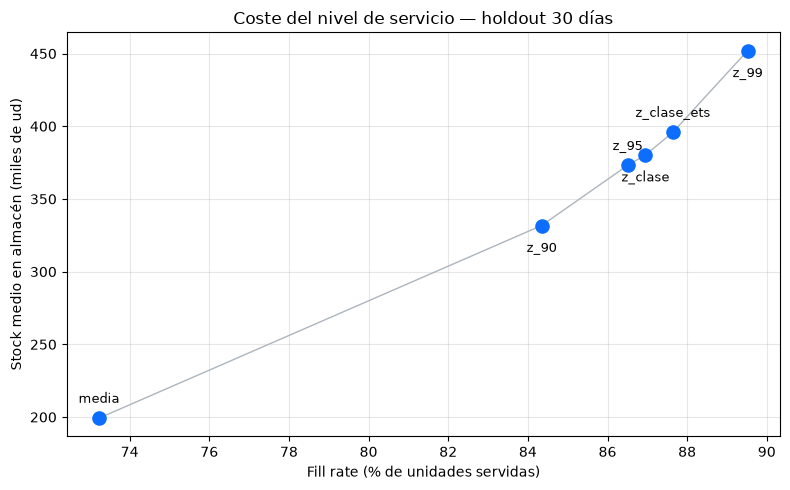

In [5]:
plot_policy_service_tradeoff(summary, save=True)

## 4. Dónde caen los quiebres

Diferenciar z por clase existe para esto: proteger a la clase A y dejar que la C absorba el faltante. La tabla dice si la política lo consigue.

In [6]:
por_clase = fill_rate_by_class(by_sku)
por_clase.pivot(index="ABCClass", columns="policy", values="fill_rate")[
    ["media", "z_90", "z_95", "z_99", "z_clase", "z_clase_ets"]
]

policy,media,z_90,z_95,z_99,z_clase,z_clase_ets
ABCClass,,,,,,
A,0.78,0.88,0.91,0.93,0.92,0.93
B,0.68,0.80,0.82,0.85,0.82,0.82
C,0.56,0.70,0.73,0.76,0.70,0.70


## 5. Los SKUs que más unidades pierden

Con la política del proyecto (`z_clase`). Son los candidatos a mirar uno a uno: o el forecast se queda corto, o el lead time de 14 días no da tiempo a reaccionar.

In [7]:
peores_cols = [
    config.COL_STOCK_CODE,
    config.COL_DESCRIPTION,
    "ABCClass",
    "forecast_daily",
    "demand_total",
    "units_lost",
    "fill_rate",
    "stockout_days",
]
(
    by_sku[by_sku["policy"] == "z_clase"]
    .sort_values("units_lost", ascending=False)[peores_cols]
    .head(15)
)

,StockCode,Description,ABCClass,forecast_daily,demand_total,units_lost,fill_rate,stockout_days
3722,22086,PAPER CHAIN KIT 50'S CHRISTMAS,A,119.27,"6,224.00","1,162.03",0.81,5
4579,23084,RABBIT NIGHT LIGHT,A,136.13,"7,191.00","1,016.01",0.86,4
4415,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,A,66.63,"3,638.00",999.27,0.73,7
3499,21705,BAG 500g SWIRLY MARBLES,B,2.77,920.00,737.44,0.20,7
5625,85123A,WHITE HANGING HEART T-LIGHT HOLDER,A,76.33,"3,597.00",723.77,0.80,5
5428,84568,GIRLS ALPHABET IRON ON PATCHES,B,2.83,846.00,665.13,0.21,10
4335,22804,PINK HANGING HEART T-LIGHT HOLDER,A,2.75,767.00,653.53,0.15,8
3890,22299,PIG KEYRING WITH LIGHT & SOUND,B,1.53,776.00,647.83,0.17,14
3621,21914,BLUE HARMONICA IN BOX,A,26.47,"1,897.00",645.60,0.66,9
3654,21977,PACK OF 60 PINK PAISLEY CAKE CASES,A,22.20,"1,501.00",608.17,0.59,10


## 6. Artefactos

In [8]:
save_processed(by_sku, "policy_simulation_by_sku.csv")
save_processed(summary, "policy_simulation_summary.csv")
save_processed(por_clase, "policy_simulation_by_class.csv")

print("Carpeta:", config.PROCESSED_DATA_DIR)

Carpeta: C:\code\proyecto-a-inventario-ecommerce\data\processed


## Lectura

- **Pedir la media no es una política**: sirve tres de cada cuatro unidades y deja casi 2,000 SKUs con algún día en quiebre. El stock de seguridad es lo que compra el servicio.
- **Cada punto de servicio se paga en stock parado**, y el precio sube: pasar de `media` a `z_clase` cuesta del orden de dos unidades en almacén por cada unidad extra servida, y de `z_clase` a `z_99` sale bastante más caro.
- **Diferenciar por clase hace lo que promete**: la clase A queda muy por encima de la C en fill rate, con menos stock total que un z = 2.33 uniforme.
- **Ninguna política llega al 90%**, y ahí el culpable no es el factor de seguridad: el holdout es la subida de Navidad, la demanda real sube por encima de la media entrenada y con 14 días de lead time no da tiempo a reaccionar. Lo que falta es nivel en el forecast, no z.

Con eso, el proyecto ya no valida solo el forecast: valida la decisión que sale de él.